https://pennylane.ai/demos/tutorial_equivariant_graph_embedding

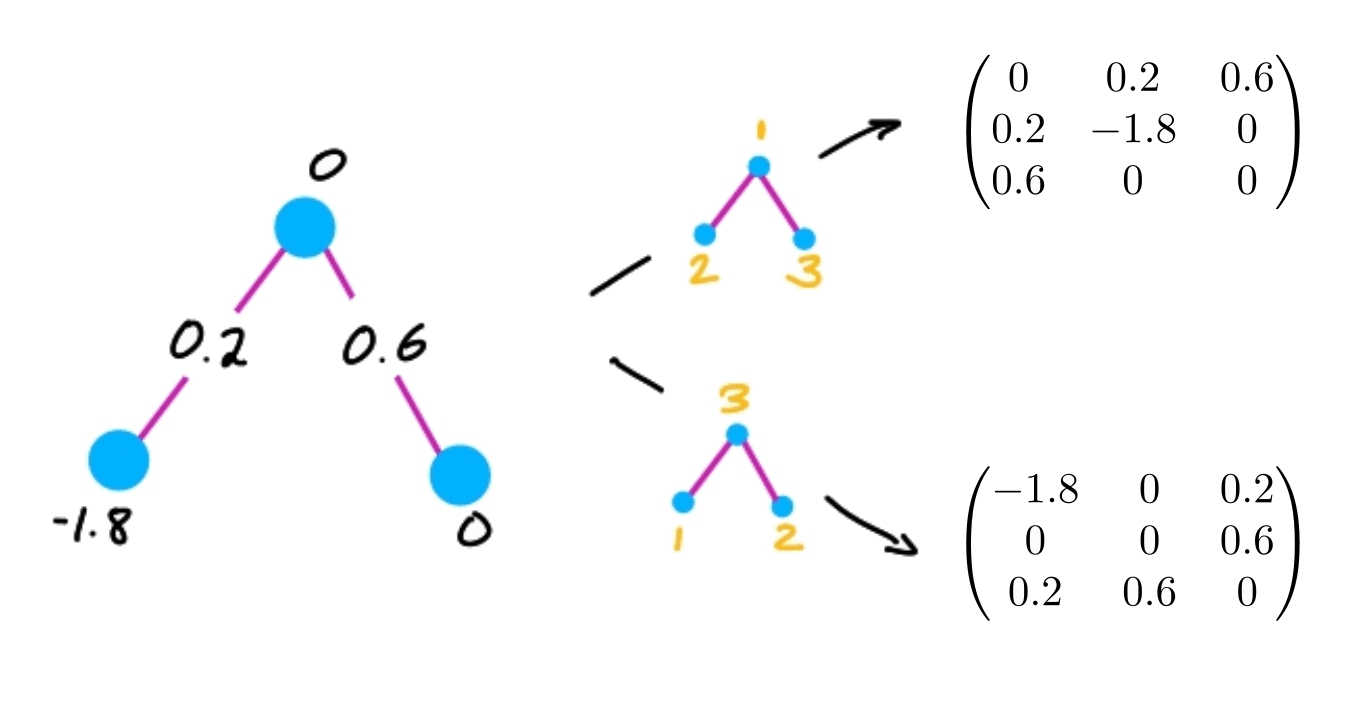

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# rng = np.random.default_rng(4324234)
rng = np.random.default_rng(99)

def create_data_point(n):
    """
    Returns a random undirected adjacency matrix of dimension (n,n).
    The diagonal elements are interpreted as node attributes.
    """
    mat = rng.random((n, n))
    A = (mat + np.transpose(mat))/2
    return np.round(A, decimals=2)

A = create_data_point(3)
print(A)

[[0.51 0.77 0.4 ]
 [0.77 0.61 0.56]
 [0.4  0.56 0.47]]


In [2]:
def permute(A, permutation):
    """
    Returns a copy of A with rows and columns swapped according to permutation.
    For example, the permutation [1, 2, 0] swaps 0->1, 1->2, 2->0.
    """

    P = np.zeros((len(A), len(A)))
    for i,j in enumerate(permutation):
        P[i,j] = 1

    return P @ A @ np.transpose(P)

A_perm = permute(A, [1, 2, 0])
print(A_perm)

[[0.61 0.56 0.77]
 [0.56 0.47 0.4 ]
 [0.77 0.4  0.51]]


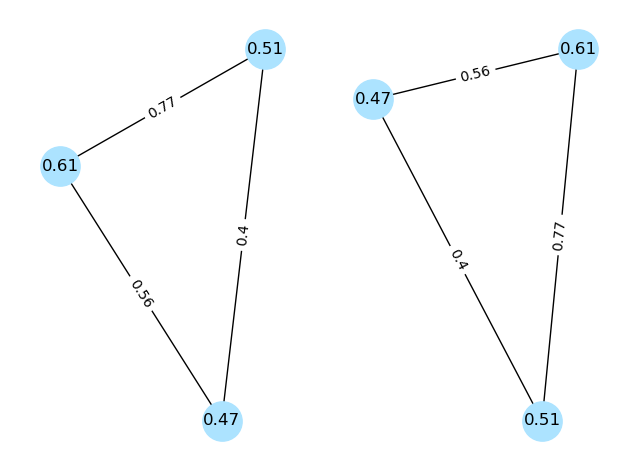

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2)

# interpret diagonal of matrix as node attributes
node_labels = {n: A[n,n] for n in range(len(A))}
np.fill_diagonal(A, np.zeros(len(A)))

G1 = nx.Graph(A)
pos1 = nx.spring_layout(G1, seed=1)
nx.draw(G1, pos1, labels=node_labels, ax=ax1, node_size = 800, node_color = "#ACE3FF")
edge_labels = nx.get_edge_attributes(G1,'weight')
nx.draw_networkx_edge_labels(G1,pos1,edge_labels=edge_labels, ax=ax1)

# interpret diagonal of permuted matrix as node attributes
node_labels = {n: A_perm[n,n] for n in range(len(A_perm))}
np.fill_diagonal(A_perm, np.zeros(len(A)))

G2 = nx.Graph(A_perm)
pos2 = nx.spring_layout(G2, seed=1)
nx.draw(G2, pos2, labels=node_labels, ax=ax2, node_size = 800, node_color = "#ACE3FF")
edge_labels = nx.get_edge_attributes(G2,'weight')
nx.draw_networkx_edge_labels(G2,pos2,edge_labels=edge_labels, ax=ax2)

ax1.set_xlim([1.2*x for x in ax1.get_xlim()])
ax2.set_xlim([1.2*x for x in ax2.get_xlim()])
plt.tight_layout()
plt.show()

In [4]:
import pennylane as qp

def perm_equivariant_embedding(A, betas, gammas):
    """
    Ansatz to embedd a graph with node and edge weights into a quantum state.

    The adjacency matrix A contains the edge weights on the off-diagonal,
    as well as the node attributes on the diagonal.

    The embedding contains trainable weights 'betas' and 'gammas'.
    """
    n_nodes = len(A)
    n_layers = len(betas) # infer the number of layers from the parameters

    # initialise in the plus state
    for i in range(n_nodes):
        qp.Hadamard(i)

    for l in range(n_layers):

        for i in range(n_nodes):
            for j in range(i):
                # factor of 2 due to definition of gate
                qp.IsingZZ(2*gammas[l]*A[i,j], wires=[i,j])

        for i in range(n_nodes):
            qp.RX(A[i,i]*betas[l], wires=i)

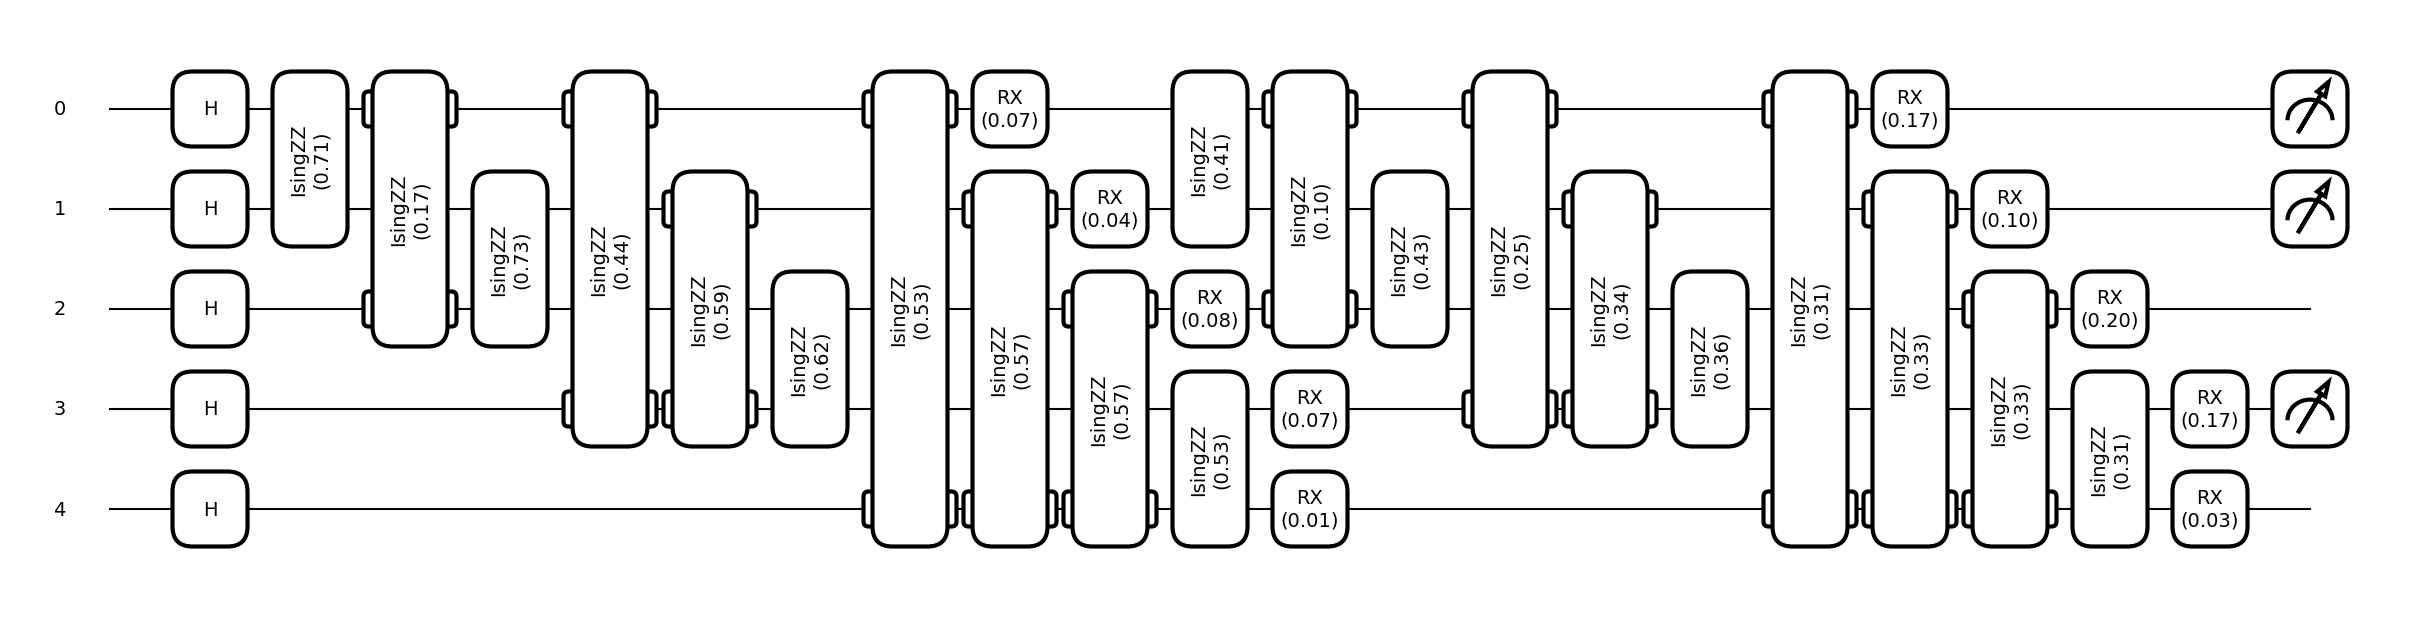

In [5]:
n_qubits = 5
n_layers = 2

dev = qp.device("lightning.qubit", wires=n_qubits)

@qp.qnode(dev)
def eqc(adjacency_matrix, observable, trainable_betas, trainable_gammas):
    """Circuit that uses the permutation equivariant embedding"""

    perm_equivariant_embedding(adjacency_matrix, trainable_betas, trainable_gammas)
    return qp.expval(observable)


A = create_data_point(n_qubits)
betas = rng.random(n_layers)
gammas = rng.random(n_layers)
observable = qp.PauliX(0) @ qp.PauliX(1) @ qp.PauliX(3)

qp.draw_mpl(eqc, decimals=2)(A, observable, betas, gammas)
plt.show()

In [6]:
A

array([[0.61, 0.6 , 0.14, 0.37, 0.45],
       [0.6 , 0.35, 0.62, 0.5 , 0.48],
       [0.14, 0.62, 0.7 , 0.52, 0.48],
       [0.37, 0.5 , 0.52, 0.6 , 0.45],
       [0.45, 0.48, 0.48, 0.45, 0.1 ]])

In [7]:
result_A = eqc(A, observable, betas, gammas)
print("Model output for A:", result_A)

Model output for A: 0.4165715671769169


In [8]:
perm = [2, 3, 0, 1, 4]
A_perm = permute(A, perm)
result_Aperm = eqc(A_perm, observable, betas, gammas)
print("Model output for permutation of A: ", result_Aperm)

Model output for permutation of A:  0.37637784684192716


In [9]:
observable_perm = qp.PauliX(perm[0]) @ qp.PauliX(perm[1]) @ qp.PauliX(perm[3])
result_Aperm = eqc(A_perm, observable_perm, betas, gammas)
print("Model output for permutation of A, and with permuted observable: ", result_Aperm)

Model output for permutation of A, and with permuted observable:  0.4165715671769168
